In [1]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

# For optimization/visualizations
import optuna
from optuna.visualization import plot_optimization_history, plot_contour, plot_param_importances

from tqdm import tqdm

In [2]:
%run three_level_freespace_funcs.py
from three_level_freespace_funcs import three_level_simulation, plot_probs

# Summary 
$$ \hat{H} = g_{ge} \alpha(t)(\hat{\sigma}_{ge}+ \hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}$$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

$$\beta(t)= -a_{factor} \cdot \frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot \text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \cdot c_{factor} \right) = a\times b \times \text{exp} (\frac{i \Delta \cdot h(t, T)}{c})$$

-  From the cooperativity document, $g_{ge} \propto \sqrt{2\gamma C}$ in free space. The same goes for $g_{se}$, but we have $\sqrt{2\gamma C_w}$ where $C_w$ is dependent on beam size. Similar gamma (dependent on Clebsch Gordon coefficients) but could have different C across the $g_{ge}$ and $g_{se}$ parameters (C_w = dependent on beam size)

## Input Signal
Currently, the input signal is a Gaussian. 

In [3]:
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)

# Returns area-normalized Lorentzian (CHECK AREA NORMALIZATION)
def lorentzian(mu, gamma, t):
    return np.sqrt(gamma/(2*np.pi)) / ( (t-mu)**2 + (gamma/2)**2 )

# Returns area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

In [4]:
# Simulation Time
time_final = 10 # total simulation time
N = 5000 # number of time steps

# System Parameters 
C = 100           # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700        # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

alpha_in_func = alpha_in # input pulse function
template_func = alpha_in # template function for calculating beta(t) (should be same as input pulse for optimal storage)

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


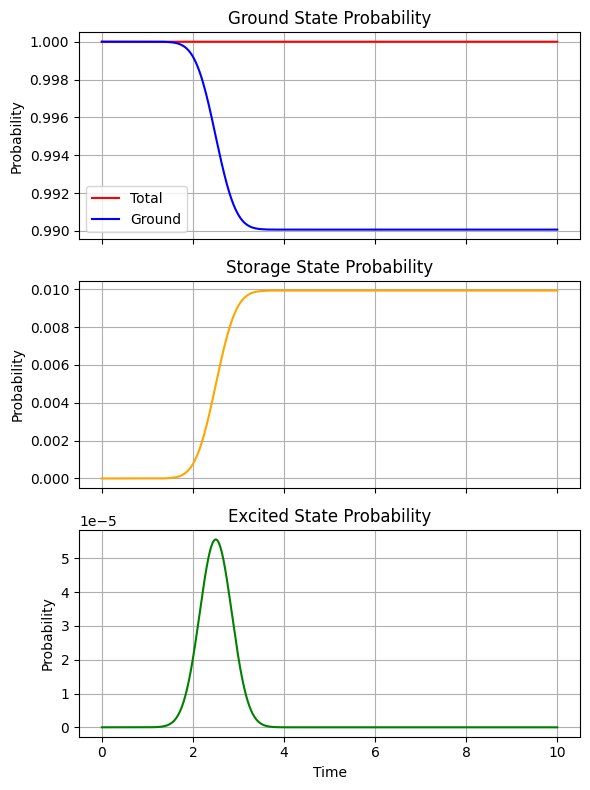

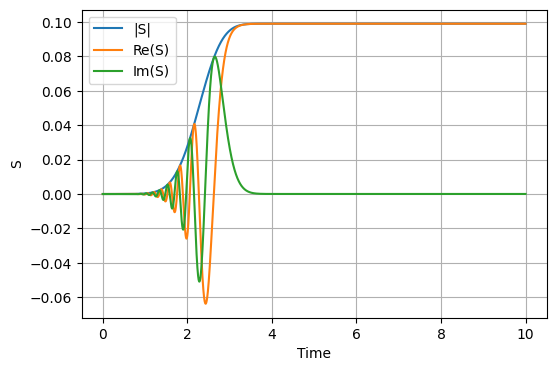

0.009932845670068554


In [5]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(abs(prob_s[-1]))

### Parameter Effects
You can see how changing the parameters $C, \Delta, \gamma$ affect performance below.

- C (efficiency should only be dependent on C): increasing C should increase the efficiency. You will notice that if you decrease cooperativity significantly, you will need to increase the resolution of your time steps (in the code, this corresponds to increasing N).
- $\Delta$ should have no explicit effect on efficiency as we account for large detuning by having $\Delta$ in the numerator of $\beta$. 



In [ ]:
C_vals =  np.linspace(0.1, 300, 50)
N=8000
prob_s_vals = []
for i in tqdm(range(len(C_vals))):
    g_ge = np.sqrt(2*C_vals[i]*gamma) # coupling strength between |g> and |e>
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C_vals[i], gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
    #print(C_vals[i],abs(prob_s[-1]))
    prob_s_vals.append(abs(prob_s[-1]))

100%|██████████| 50/50 [03:57<00:00,  4.74s/it]


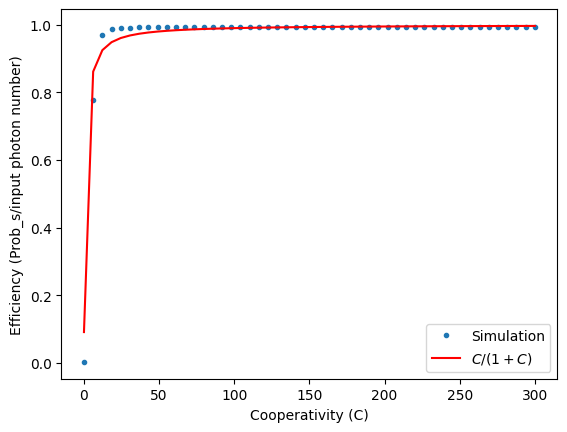

In [49]:
plt.plot(C_vals, np.array(prob_s_vals)/0.01, '.', label='Simulation') # normalize by input photon number (0.01 for amp=0.1)
plt.plot(C_vals, C_vals/(1+C_vals), color='red', label=r'$C/(1+C)$') # theoretical limit for large detuning
plt.ylabel('Efficiency (Prob_s/input photon number)'); plt.xlabel('Cooperativity (C)')
plt.legend()

In [ ]:
detuning_vals =  np.linspace(100, 1000, 50)
prob_s_vals = []
for i in tqdm(range(len(detuning_vals))):
    g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>
    time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, detuning_vals[i], time_final, T, N, g_se, g_ge, alpha_in_func, template_func)
    prob_s_vals.append(abs(prob_s[-1]))

100%|██████████| 50/50 [02:51<00:00,  3.43s/it]


Text(0.5, 0, 'Detuning')

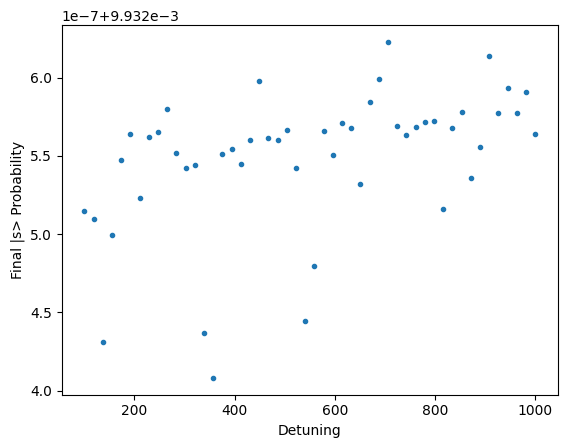

In [16]:
plt.plot(detuning_vals, prob_s_vals, '.')
plt.ylabel('Final |s> Probability'); plt.xlabel('Detuning')

## Testing Other Templates

Lorentzian, etc.

In [10]:
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)

### INPUT COHERENT STATE
def alpha_in_other(t):
    amp = 0.1 # small amplitude
    #return amp*gaussian(mu, sigma, t) * np.sin(t-mu) # orthogonal to original Gaussian
    return amp*lorentzian(mu, sigma, t)
    
time = np.linspace(0, time_final, N)
print("Area of alpha:", integrate.simps((alpha_in_other(time))**2, time))

### SIMULATION PARAMETERS
time_final = 10 # total simulation time
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)
N = 5000 # number of time steps

### SYSTEM PARAMETERS
C = 100           # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700        # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

Area of alpha: 0.07998259710787592


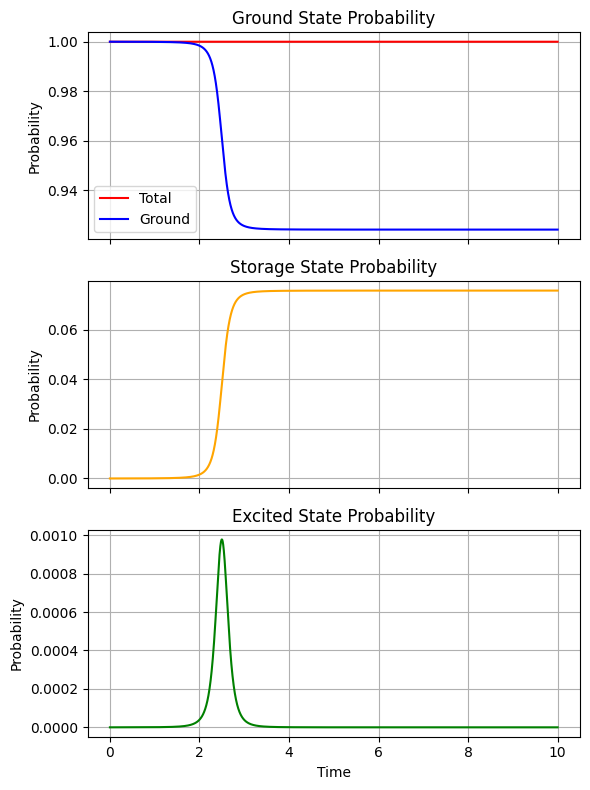

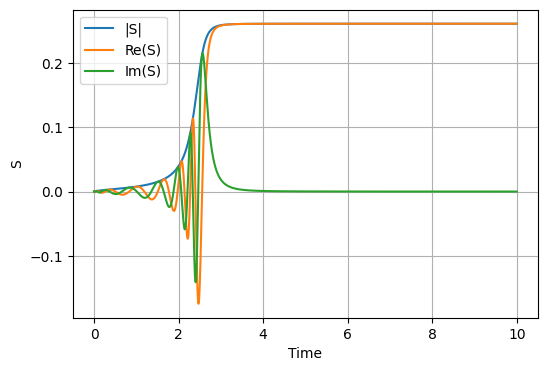

0.0758353791511943


In [11]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_other, alpha_in_other)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(abs(prob_s[-1]))

## Orthogonal Templates
Orthogonal input signal given by a Gaussian times a sin function (see 2LS for more detail). Behaves as expected: the storage state starts to store a little but ultimately rejects the signal because it is orthogonal. Details of this still need to be ironed out as parts of this still confuse me. 

In [8]:
mu, sigma = 2.5, 0.5 # defined for a Gaussian input pulse
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)

### INPUT COHERENT STATE
def alpha_in_orthogonal(t):
    amp = 0.1 # small amplitude
    return amp*gaussian(mu, sigma, t) * np.sin(t-mu) # orthogonal to original Gaussian
    
time = np.linspace(0, time_final, N)
print("Area of alpha:", integrate.simps((alpha_in_orthogonal(time))**2, time))

### SIMULATION PARAMETERS
time_final = 10 # total simulation time
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)
N = 5000 # number of time steps

### SYSTEM PARAMETERS
C = 100           # cooperativity (higher = more efficient)
gamma = 1       # decay rate
Delta = 700        # detuning

g_se = 1  # coupling strength between |s> and |e>
g_ge = np.sqrt(2*C*gamma) # coupling strength between |g> and |e>

Area of alpha: 0.0011059960846405642


C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\cbook\__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


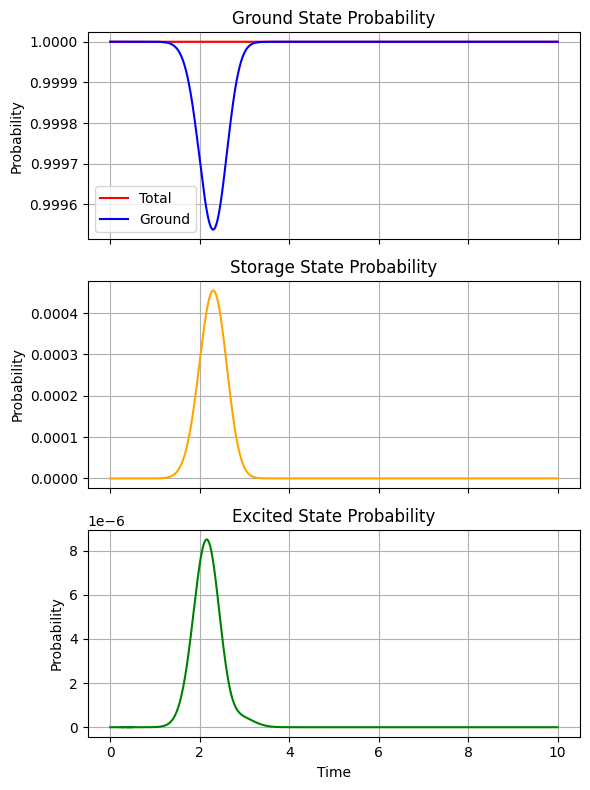

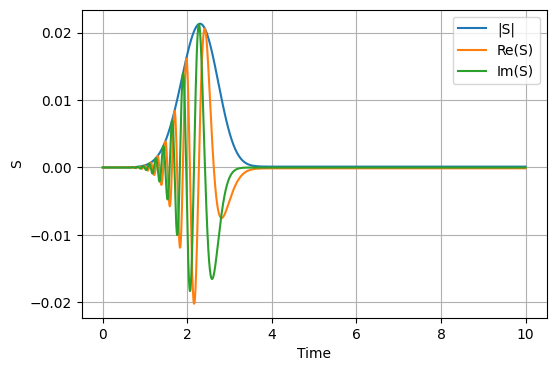

1.0941971522754571e-07


In [9]:
time, S, prob_s, prob_g, prob_e = three_level_simulation(C, gamma, Delta, time_final, T, N, g_se, g_ge, alpha_in_orthogonal, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(abs(prob_s[-1]))

## Miscellaneous
### Using Optuna
Performs parallelization and Bayesian optimization. Other options: random sampling.

In [17]:
a_factor_vals =  np.linspace(0.01, 5, 50)
c_factor_vals =  np.linspace(0.01, 5, 50)
Delta_vals = np.linspace(100, 1000, 100)
T, g_se = 10, 1
C = 100
gamma = 1

def objective_optuna(trial):
    c_factor = trial.suggest_float("c_factor", min(c_factor_vals), max(c_factor_vals))
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    Delta = trial.suggest_float("Delta", min(Delta_vals), max(Delta_vals))
    g_ge = np.sqrt(2*gamma*C)

    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1
print(study.best_params)
print(study.best_value)

[I 2026-03-25 10:41:07,757] A new study created in memory with name: no-name-064c327d-20f0-4f9d-a529-aef7189021d3
C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:65: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:69: ComplexWarning:

Casting complex values to real discards the imaginary part

C:\Users\bac06\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\optuna\study\_tell.py:166: ComplexWarning:

Casting complex values to real discards the imaginary part

[I 2026-03-25 10:41:11,757] Trial 0 finished with value: 7.201048793642333e-05 and parameters: {'c_factor': 2.658617121556094, 'a_factor': 4.346071241543307, '

{'c_factor': 0.9868926696860765, 'a_factor': 0.9076143358094861, 'Delta': 731.6112717823485}
0.009817440314894654


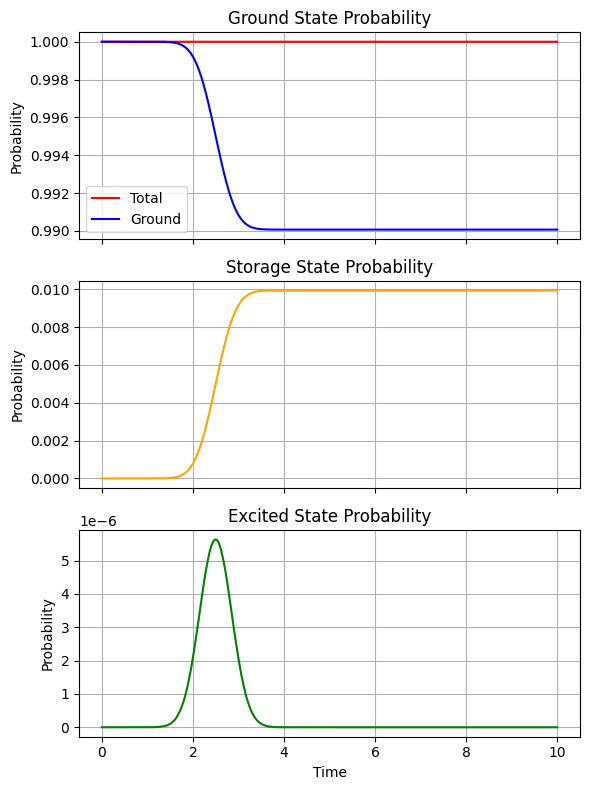

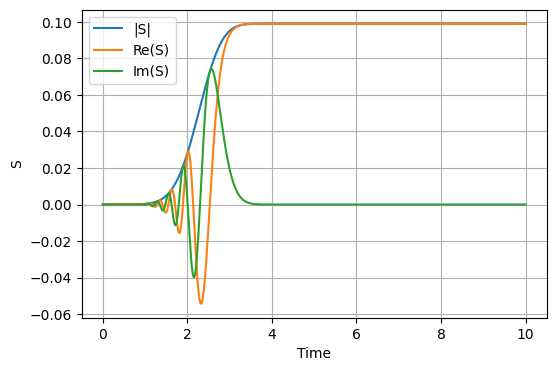

(0.009933456912511462-1.921353855328271e-18j)


In [ ]:
T, g_se = 10, 1
C = 100
gamma = 1
g_ge = np.sqrt(2*gamma*C)
c_factor = 1 #study.best_params['c_factor']
a_factor = 1 #study.best_params['a_factor']
Delta = 5000 # study.best_params['Delta']

time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in)
plot_probs(time, prob_g, prob_e, prob_s, S)
print(prob_s[-1])

In [ ]:
#plot_contour(study, params=["a_factor", "C"])
#plot_optimization_history(study).show()
#plot_param_importances(study).show()